# Методы кластеризации для сегментации изображений

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import SpectralClustering
import time
import os

📝 Создаём тестовое изображение...


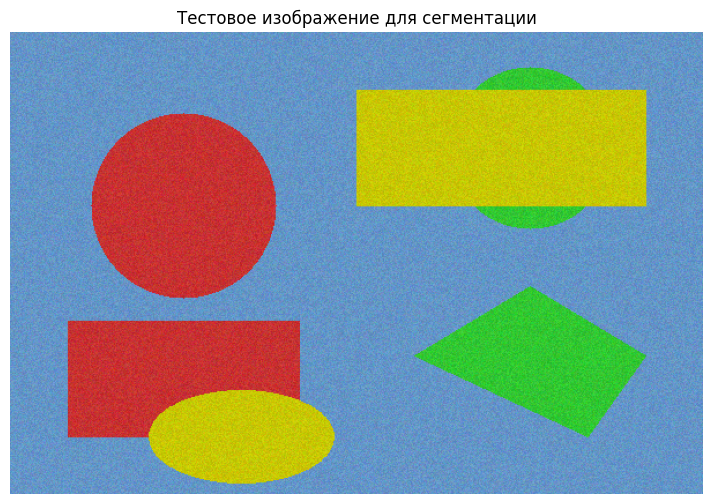

In [2]:
# ===============================
# Создание тестового изображения
# ===============================

def create_segmentation_test_image():
    """Создаёт тестовое изображение для сегментации"""

    print("📝 Создаём тестовое изображение...")

    img = np.zeros((400, 600, 3), dtype=np.uint8)

    # Фон - голубой
    img[:, :] = [200, 150, 100]

    # Красный объект
    cv2.circle(img, (150, 150), 80, (50, 50, 200), -1)
    cv2.rectangle(img, (50, 250), (250, 350), (50, 50, 200), -1)

    # Зелёный объект
    cv2.circle(img, (450, 100), 70, (50, 200, 50), -1)
    points = np.array([[350, 280], [450, 220], [550, 280], [500, 350]], np.int32)
    cv2.fillPoly(img, [points], (50, 200, 50))

    # Жёлтый объект
    cv2.rectangle(img, (300, 50), (550, 150), (0, 200, 200), -1)
    cv2.ellipse(img, (200, 350), (80, 40), 0, 0, 360, (0, 200, 200), -1)

    # Добавляем шум
    noise = np.random.randint(-20, 20, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

img = create_segmentation_test_image()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title('Тестовое изображение для сегментации')
plt.axis('off')
plt.show()

🔄 Выполняем K-Means (K=2)...
   Итерация 0: сдвиг центроидов = 111.986824
   ✅ Сходимость на итерации 7

K = 2:
   Инерция (WCSS): 9.01e+08
   Уникальные цвета: 2
🔄 Выполняем K-Means (K=3)...
   Итерация 0: сдвиг центроидов = 160.942215
   ✅ Сходимость на итерации 3

K = 3:
   Инерция (WCSS): 3.61e+08
   Уникальные цвета: 3
🔄 Выполняем K-Means (K=4)...
   Итерация 0: сдвиг центроидов = 136.273682
   Итерация 10: сдвиг центроидов = 0.125355
   ✅ Сходимость на итерации 14

K = 4:
   Инерция (WCSS): 5.15e+08
   Уникальные цвета: 4
🔄 Выполняем K-Means (K=5)...
   Итерация 0: сдвиг центроидов = 236.603363
   Итерация 10: сдвиг центроидов = 0.467043
   Итерация 20: сдвиг центроидов = 0.289875
   Итерация 30: сдвиг центроидов = 0.098724
   Итерация 40: сдвиг центроидов = 0.016081
   ✅ Сходимость на итерации 46

K = 5:
   Инерция (WCSS): 3.36e+08
   Уникальные цвета: 5
🔄 Выполняем K-Means (K=6)...
   Итерация 0: сдвиг центроидов = 244.951584
   Итерация 10: сдвиг центроидов = 0.879097
   Итера

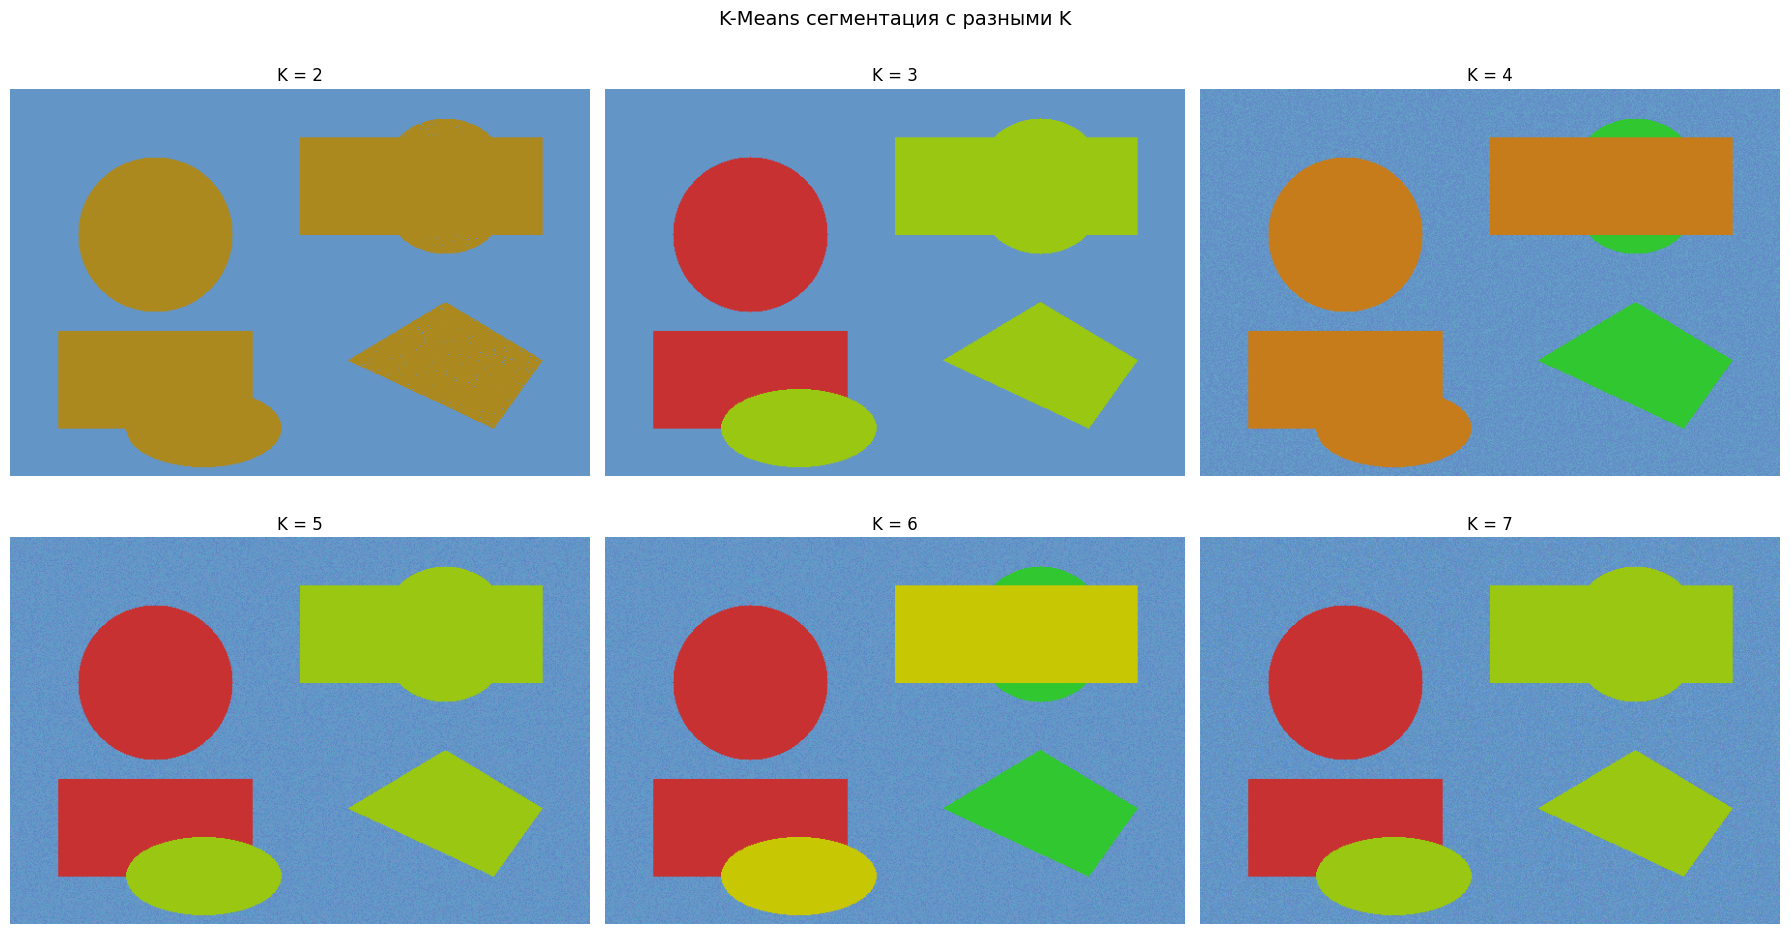

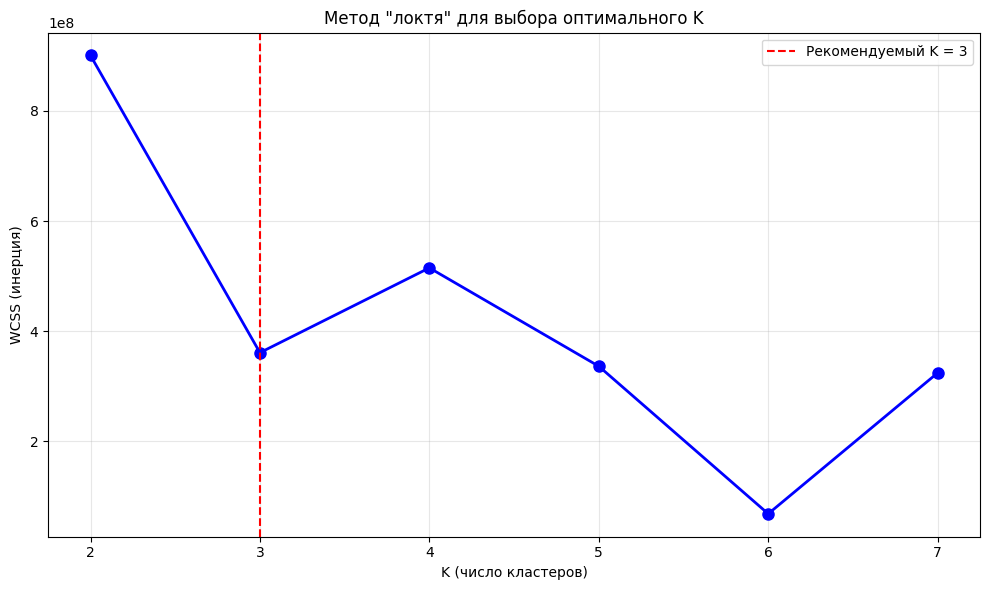


🔄 Сравнение с OpenCV cv2.kmeans()...


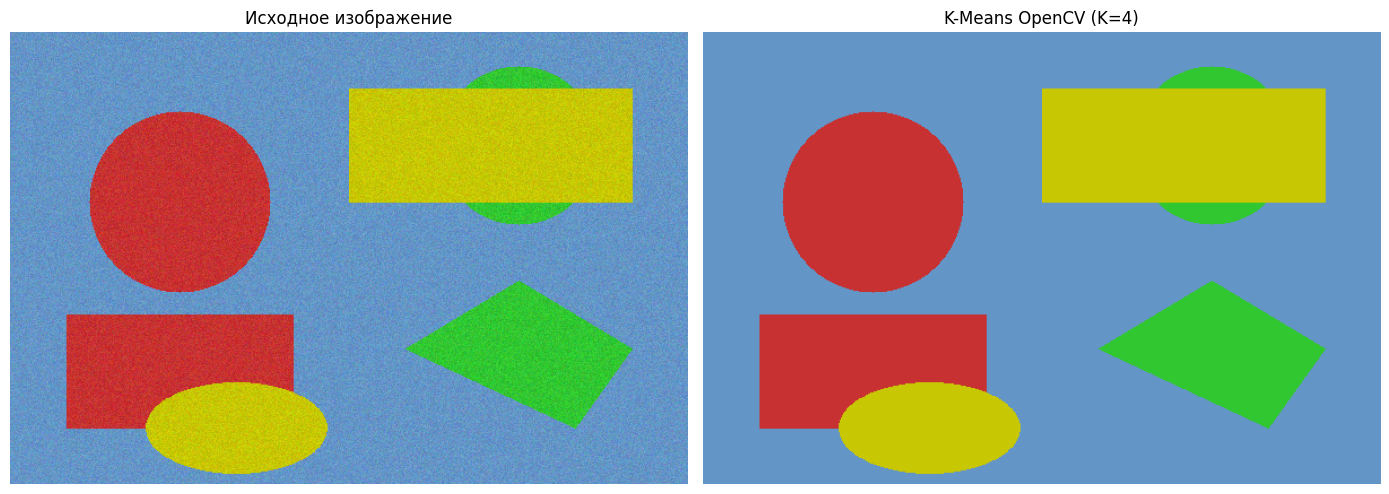

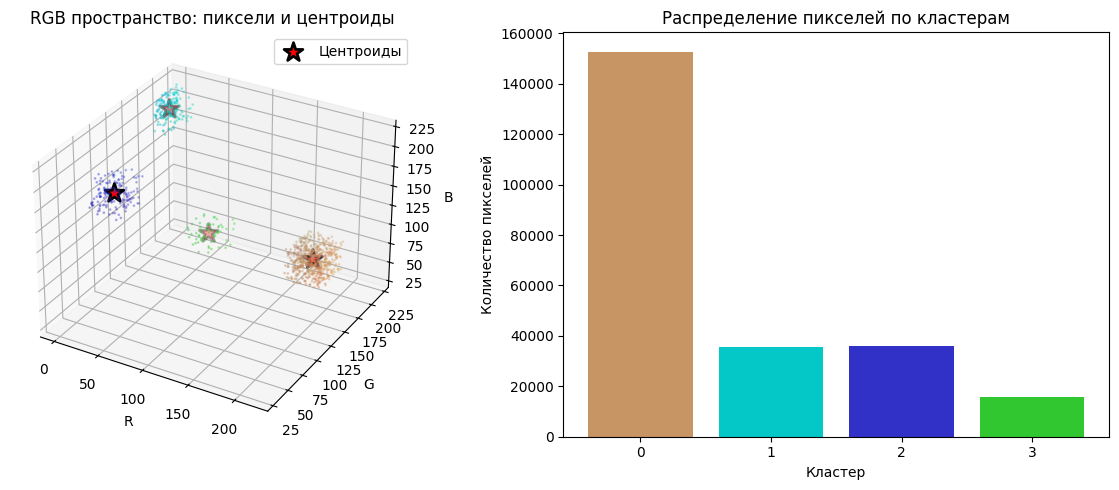

In [3]:
# ===============================
# ЗАДАНИЕ 1: K-Means кластеризация
# ===============================

def kmeans_manual(pixels, K=3, max_iter=100, epsilon=0.001):
    """
    Реализация K-Means "с нуля"

    Args:
        pixels: матрица пикселей (N×3 для RGB)
        K: количество кластеров
        max_iter: максимальное число итераций
        epsilon: порог сходимости

    Returns:
        labels: метки кластеров для каждого пикселя
        centers: центроиды кластеров
        inertia: сумма квадратов расстояний
    """

    N = len(pixels)

    # 1. Инициализация: случайно выбираем K пикселей как центроиды
    indices = np.random.choice(N, K, replace=False)
    centers = pixels[indices].astype(np.float32)

    print(f"🔄 Выполняем K-Means (K={K})...")

    for iteration in range(max_iter):
        # 2. Назначение: каждому пикселю - ближайший центроид
        distances = np.zeros((N, K))

        for k in range(K):
            distances[:, k] = np.sum((pixels - centers[k])**2, axis=1)

        labels = np.argmin(distances, axis=1)

        # 3. Обновление центроидов
        new_centers = np.zeros_like(centers)

        for k in range(K):
            cluster_pixels = pixels[labels == k]

            if len(cluster_pixels) > 0:
                new_centers[k] = np.mean(cluster_pixels, axis=0)
            else:
                # Если кластер пуст, генерируем новый случайный центроид
                new_centers[k] = pixels[np.random.randint(0, N)]

        # 4. Проверка сходимости
        center_shift = np.sum(np.sqrt(np.sum((new_centers - centers)**2, axis=1)))

        if iteration % 10 == 0:
            print(f"   Итерация {iteration}: сдвиг центроидов = {center_shift:.6f}")

        if center_shift < epsilon:
            print(f"   ✅ Сходимость на итерации {iteration}")
            break

        centers = new_centers

    # Вычисляем инерцию (WCSS)
    distances = np.zeros((N, K))
    for k in range(K):
        distances[:, k] = np.sum((pixels - centers[k])**2, axis=1)

    inertia = np.sum(np.min(distances, axis=1))

    return labels, centers, inertia

# Подготавливаем пиксели
pixels = img.reshape(-1, 3).astype(np.float32)

# Применяем K-Means для разных K
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

wcss_values = []
K_values = range(2, 8)

for i, K in enumerate(K_values):
    labels, centers, inertia = kmeans_manual(pixels, K=K, max_iter=100)
    wcss_values.append(inertia)

    # Восстанавливаем сегментированное изображение
    centers = centers.astype(np.uint8)
    segmented = centers[labels]
    segmented_img = segmented.reshape(img.shape)

    # Визуализируем
    row, col = i // 3, i % 3
    axes[row, col].imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f'K = {K}')
    axes[row, col].axis('off')

    print(f"\nK = {K}:")
    print(f"   Инерция (WCSS): {inertia:.2e}")
    print(f"   Уникальные цвета: {len(np.unique(labels))}")

plt.suptitle('K-Means сегментация с разными K', fontsize=14)
plt.tight_layout()
plt.show()

# Метод "локтя" для выбора оптимального K
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(K_values, wcss_values, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('K (число кластеров)')
ax.set_ylabel('WCSS (инерция)')
ax.set_title('Метод "локтя" для выбора оптимального K')
ax.grid(True, alpha=0.3)

# Пытаемся найти "локоть"
slopes = np.diff(wcss_values) / np.diff(K_values)
elbow_idx = np.argmax(np.diff(slopes)) + 1
elbow_K = K_values[elbow_idx]

ax.axvline(elbow_K, color='r', linestyle='--', label=f'Рекомендуемый K = {elbow_K}')
ax.legend()

plt.tight_layout()
plt.show()

# Сравнение с OpenCV
print("\n🔄 Сравнение с OpenCV cv2.kmeans()...")

K = 4
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

ret, labels_cv, centers_cv = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)

centers_cv = centers_cv.astype(np.uint8)
segmented_cv = centers_cv[labels_cv.flatten()]
segmented_img_cv = segmented_cv.reshape(img.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(segmented_img_cv, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'K-Means OpenCV (K={K})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Визуализация кластеров в 3D RGB пространстве
fig = plt.figure(figsize=(12, 5))

# Исходные точки
ax1 = fig.add_subplot(121, projection='3d')
sample_idx = np.random.choice(len(pixels), 1000, replace=False)
ax1.scatter(pixels[sample_idx, 0], pixels[sample_idx, 1], pixels[sample_idx, 2],
           c=pixels[sample_idx]/255, s=1, alpha=0.3)
ax1.scatter(centers_cv[:, 0], centers_cv[:, 1], centers_cv[:, 2],
           c='red', s=200, marker='*', edgecolors='black', linewidth=2, label='Центроиды')
ax1.set_xlabel('R')
ax1.set_ylabel('G')
ax1.set_zlabel('B')
ax1.set_title('RGB пространство: пиксели и центроиды')
ax1.legend()

# Распределение пикселей по кластерам
ax2 = fig.add_subplot(122)
unique, counts = np.unique(labels_cv, return_counts=True)
colors = centers_cv.astype(np.uint8)[unique] / 255
bars = ax2.bar(unique, counts, color=colors)
ax2.set_xlabel('Кластер')
ax2.set_ylabel('Количество пикселей')
ax2.set_title('Распределение пикселей по кластерам')
ax2.set_xticks(unique)

plt.tight_layout()
plt.show()

Используем подмножество 2000 пикселей для демонстрации
🔄 Выполняем иерархическую кластеризацию (метод: ward)...


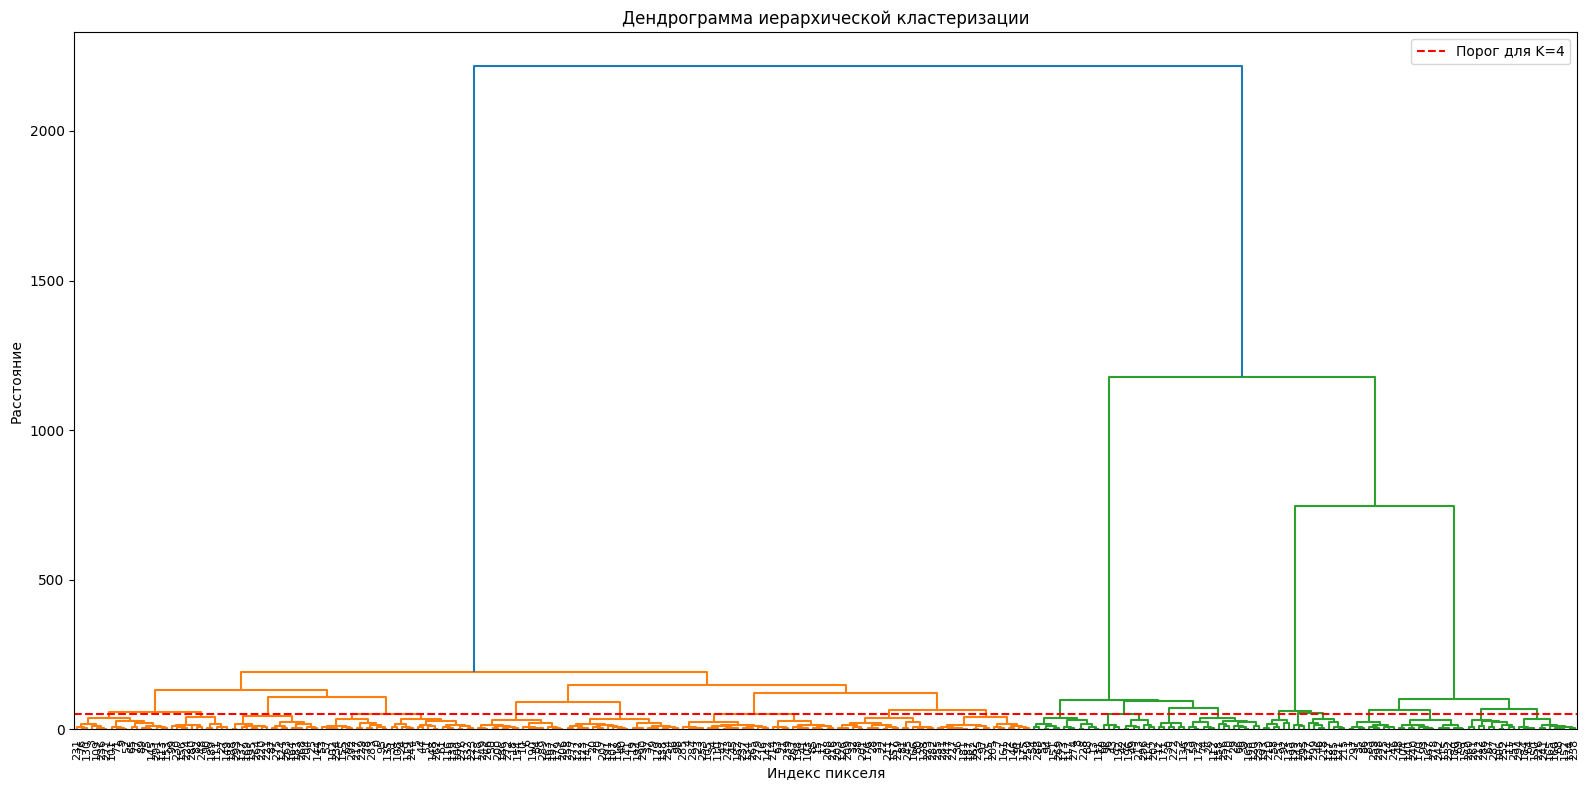

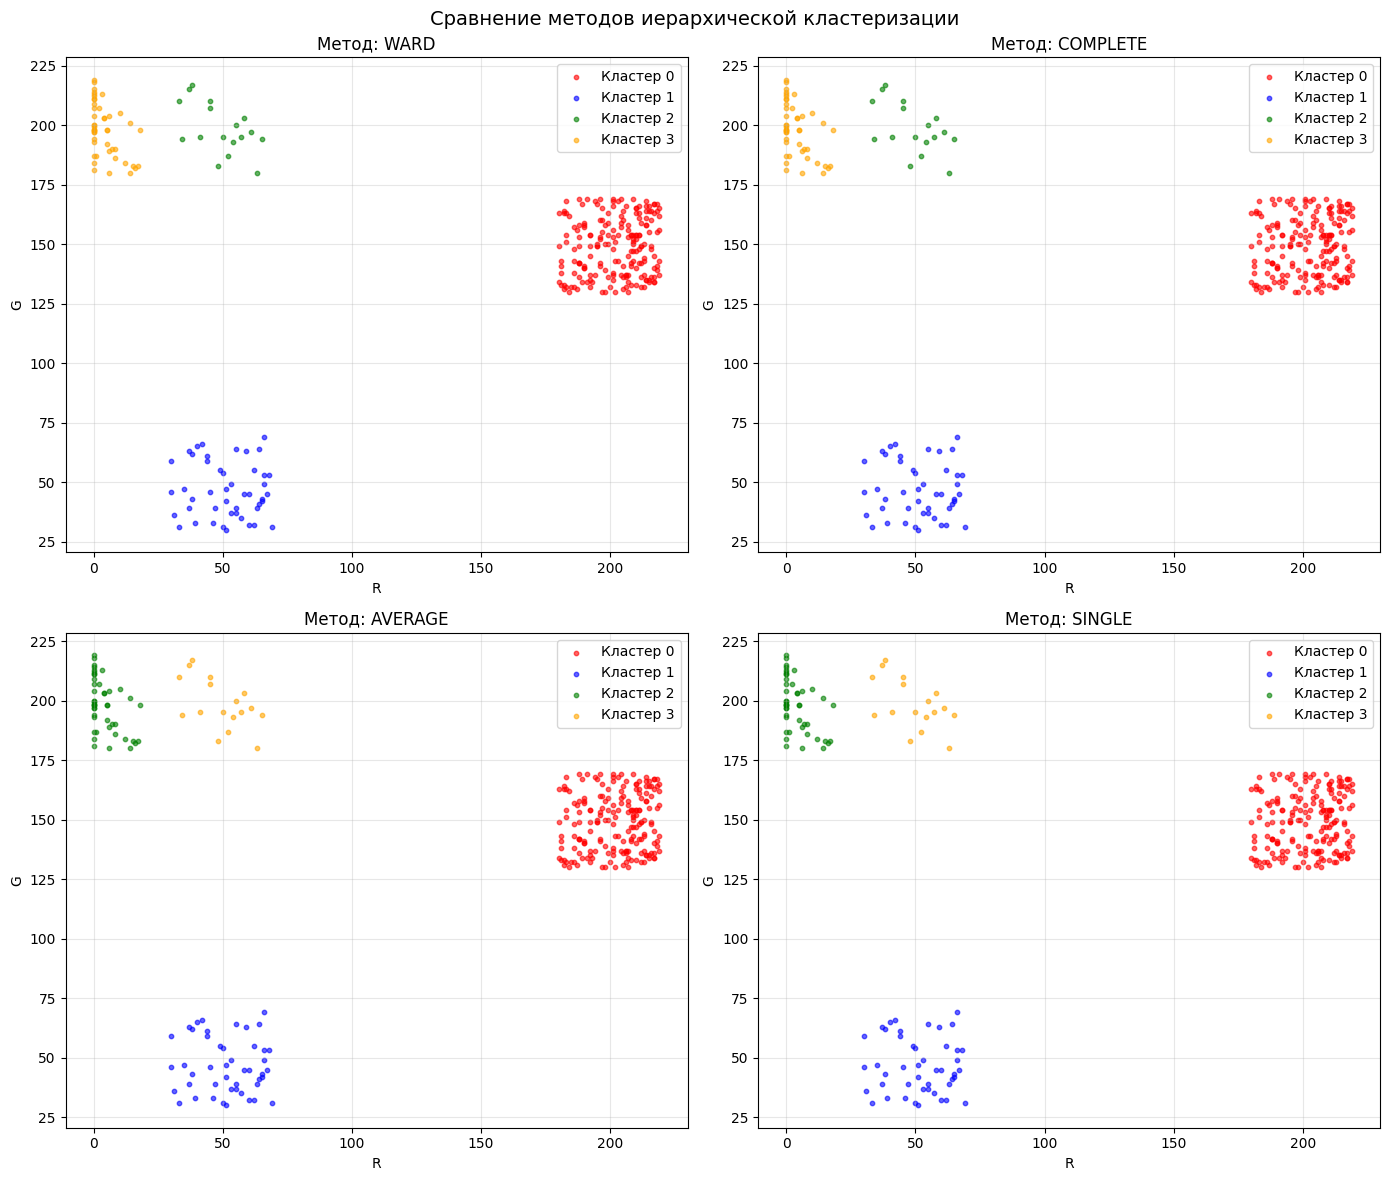

In [4]:
# ===============================
# ЗАДАНИЕ 2: Иерархическая кластеризация
# ===============================

def hierarchical_clustering_manual(pixels, K, method='ward'):
    """
    Упрощённая иерархическая кластеризация (агломеративная)

    Примечание: используем scipy для вычисления, но показываем концепцию
    """

    print(f"🔄 Выполняем иерархическую кластеризацию (метод: {method})...")

    # Выполняем иерархическую кластеризацию
    Z = linkage(pixels, method=method)

    # Получаем метки кластеров
    labels = fcluster(Z, K, criterion='maxclust') - 1

    return labels, Z

# Применяем иерархическую кластеризацию (на подмножестве для скорости)
sample_size = 2000
sample_idx = np.random.choice(len(pixels), sample_size, replace=False)
pixels_sample = pixels[sample_idx]

K = 4

print(f"Используем подмножество {sample_size} пикселей для демонстрации")

labels_hier, Z = hierarchical_clustering_manual(pixels_sample, K, method='ward')

# Визуализируем дендрограмму (на еще большем подмножестве для читаемости)
sample_size_dendro = 300
sample_idx_dendro = np.random.choice(len(pixels), sample_size_dendro, replace=False)
pixels_dendro = pixels[sample_idx_dendro]

Z_dendro = linkage(pixels_dendro, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))

dendrogram(Z_dendro, ax=ax, leaf_font_size=8)
ax.axhline(y=50, color='r', linestyle='--', label='Порог для K=4')
ax.set_title('Дендрограмма иерархической кластеризации')
ax.set_xlabel('Индекс пикселя')
ax.set_ylabel('Расстояние')
ax.legend()

plt.tight_layout()
plt.show()

# Сравнение разных методов иерархической кластеризации
methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, method in enumerate(methods):
    Z = linkage(pixels_dendro, method=method)
    labels = fcluster(Z, K, criterion='maxclust') - 1

    # Отмечаем точки разных кластеров разными цветами
    ax = axes[i]
    colors = ['red', 'blue', 'green', 'orange', 'purple'][:K]

    for k in range(K):
        mask = labels == k
        ax.scatter(pixels_dendro[mask, 0], pixels_dendro[mask, 1],
                  c=colors[k], label=f'Кластер {k}', alpha=0.6, s=10)

    ax.set_title(f'Метод: {method.upper()}')
    ax.set_xlabel('R')
    ax.set_ylabel('G')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение методов иерархической кластеризации', fontsize=14)
plt.tight_layout()
plt.show()

🔄 Выполняем спектральную кластеризацию (K=4, sigma=10.0)...
   Используем 5000 пикселей
🔄 Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
   Используем 5000 пикселей
🔄 Выполняем спектральную кластеризацию (K=4, sigma=40.0)...
   Используем 5000 пикселей
🔄 Выполняем спектральную кластеризацию (K=4, sigma=60.0)...
   Используем 5000 пикселей


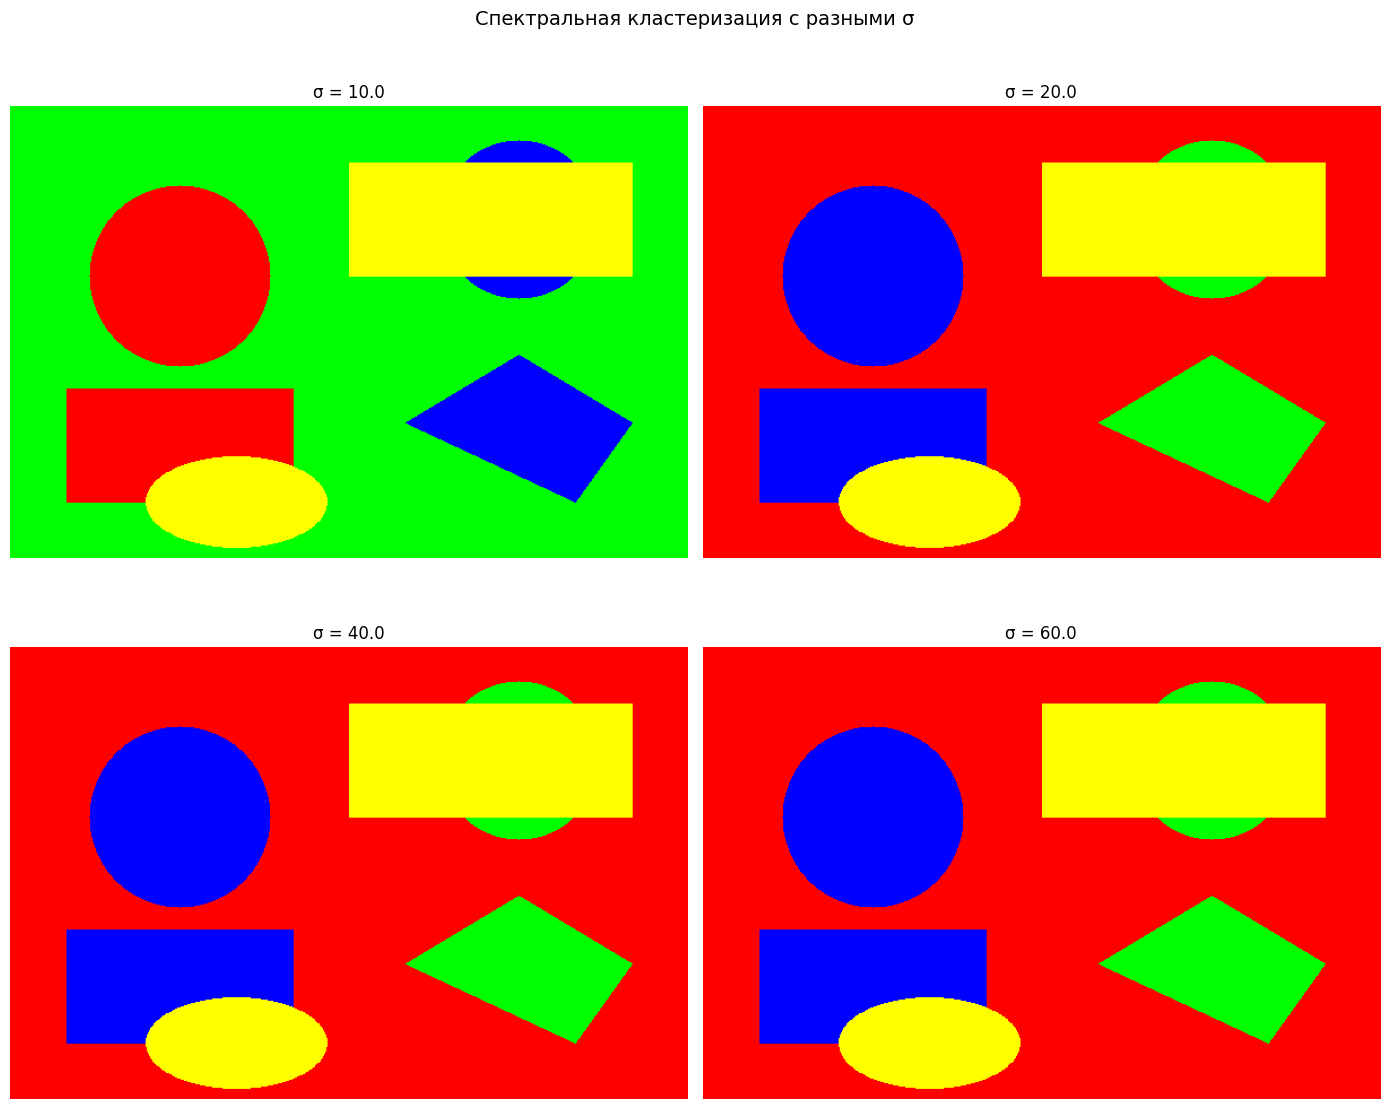


🔍 СРАВНЕНИЕ ТРЁХ МЕТОДОВ:

1. K-Means:
2. Иерархическая:
3. Спектральная:
🔄 Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
   Используем 5000 пикселей


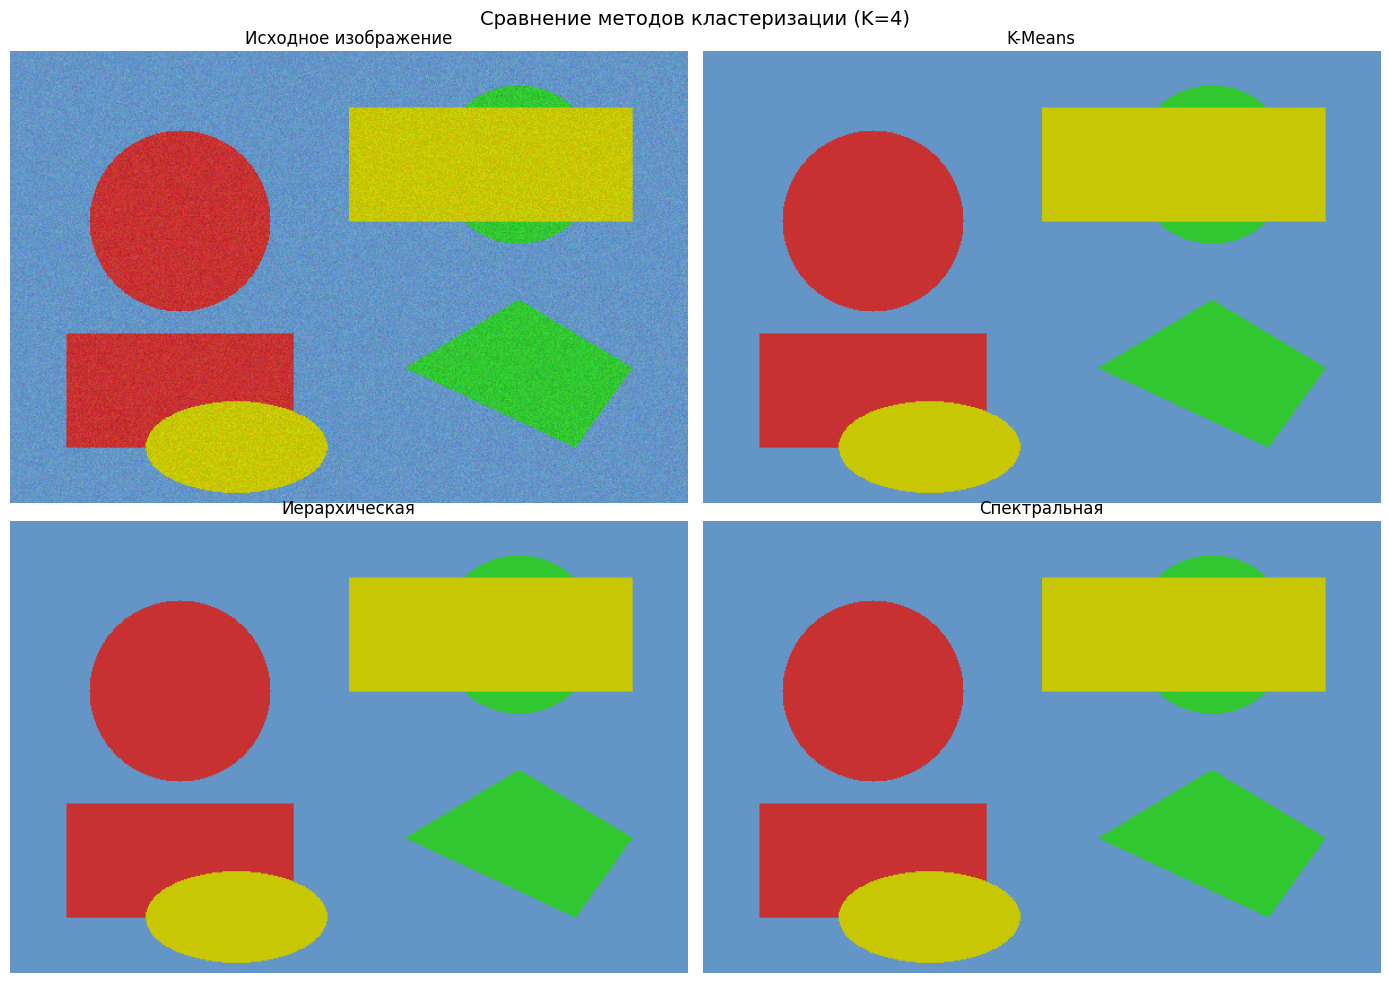

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import SpectralClustering
import time
import os
from sklearn.neighbors import NearestNeighbors

# ===============================
# ЗАДАНИЕ 3: Спектральная кластеризация
# ===============================

def spectral_clustering_image(pixels, K, sigma=1.0):
    """
    Спектральная кластеризация для изображения

    Args:
        pixels: матрица пикселей (N×3)
        K: количество кластеров
        sigma: параметр подобия в RBF ядре
    """

    print(f"🔄 Выполняем спектральную кластеризацию (K={K}, sigma={sigma})...")

    # Используем scikit-learn для спектральной кластеризации
    n_samples = min(len(pixels), 5000)  # Ограничиваем размер для скорости
    sample_idx = np.random.choice(len(pixels), n_samples, replace=False)
    pixels_sample = pixels[sample_idx]

    print(f"   Используем {n_samples} пикселей")

    # Спектральная кластеризация
    spectral = SpectralClustering(n_clusters=K, affinity='rbf', gamma=1/(2*sigma**2),
                                 random_state=42, n_init=10)
    labels_sample = spectral.fit_predict(pixels_sample)

    # Распространяем на все пиксели (используя ближайших соседей)
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(pixels_sample)

    distances, indices = nn.kneighbors(pixels)
    labels = labels_sample[indices.flatten()]

    return labels, labels_sample, pixels_sample

# Применяем спектральную кластеризацию с разными параметрами sigma
sigmas = [10.0, 20.0, 40.0, 60.0]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

K = 4

for i, sigma in enumerate(sigmas):
    labels, _, _ = spectral_clustering_image(pixels, K, sigma=sigma)

    # Раскрашиваем пиксели в цвета их кластеров
    colors_palette = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0],
                               [255, 0, 255], [0, 255, 255]])

    colored = colors_palette[labels % len(colors_palette)]
    spectral_img = colored.reshape(img.shape)

    axes[i].imshow(spectral_img)
    axes[i].set_title(f'σ = {sigma}')
    axes[i].axis('off')

plt.suptitle('Спектральная кластеризация с разными σ', fontsize=14)
plt.tight_layout()
plt.show()

# Сравнение всех трёх методов
print("\n🔍 СРАВНЕНИЕ ТРЁХ МЕТОДОВ:")

K = 4

# K-Means
print("\n1. K-Means:")
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
ret, labels_km, centers_km = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
centers_km = centers_km.astype(np.uint8)
segmented_km = centers_km[labels_km.flatten()].reshape(img.shape)

# Иерархическая
print("2. Иерархическая:")
sample_size_hier = 2000
sample_idx_hier = np.random.choice(len(pixels), sample_size_hier, replace=False)
pixels_hier_sample = pixels[sample_idx_hier]

Z = linkage(pixels_hier_sample, method='ward')
labels_hier_sample = fcluster(Z, K, criterion='maxclust') - 1
nn_hier = NearestNeighbors(n_neighbors=1)
nn_hier.fit(pixels_hier_sample)
distances_hier, indices_hier = nn_hier.kneighbors(pixels)
labels_hier_full = labels_hier_sample[indices_hier.flatten()]

centers_hier = np.array([np.mean(pixels[labels_hier_full == k], axis=0) for k in range(K)]).astype(np.uint8)
segmented_hier = centers_hier[labels_hier_full].reshape(img.shape)

# Спектральная
print("3. Спектральная:")
labels_spec, _, _ = spectral_clustering_image(pixels, K, sigma=20.0)
centers_spec = np.array([np.mean(pixels[labels_spec == k], axis=0) for k in range(K)]).astype(np.uint8)
segmented_spec = centers_spec[labels_spec].reshape(img.shape)

# Визуализируем
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Исходное изображение')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(segmented_km, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('K-Means')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(segmented_hier, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Иерархическая')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(segmented_spec, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Спектральная')
axes[1, 1].axis('off')

plt.suptitle('Сравнение методов кластеризации (K=4)', fontsize=14)
plt.tight_layout()
plt.show()

# ДОМАШНЕЕ ЗАДАНИЕ

1. Реализуйте метод силуэта (silhouette score) для оценки качества кластеризации

2. Сравните производительность всех методов:
- Время выполнения
- Качество сегментации (валидация)
- Масштабируемость с размером изображения

3. Применяйте методы к реальным изображениям:
- Портреты (выделение кожи)
- Пейзажи (выделение неба, земли)
- Сложные сцены


In [6]:
from scipy.spatial.distance import cdist

def silhouette_samples(X, labels, metric='euclidean', sample_size=None, random_state=0):
    X = np.asarray(X)
    labels = np.asarray(labels)
    n = len(labels)
    if sample_size is not None and sample_size < n:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(n, size=sample_size, replace=False)
        Xs = X[idx]
        labs = labels[idx]
        compute_all = False
    else:
        idx = np.arange(n)
        Xs = X
        labs = labels
        compute_all = True

    unique_labels = np.unique(labels)
    K = len(unique_labels)
    if K == 1:
        return np.zeros(len(Xs))

    dists = cdist(Xs, X, metric=metric)

    silhouettes = np.zeros(len(Xs), dtype=float)
    for i in range(len(Xs)):
        lab_i = labs[i]
        same_mask = (labels == lab_i)
        if np.sum(same_mask) > 1:
            a = np.sum(dists[i, same_mask]) / (np.sum(same_mask) - (1 if compute_all else 0))
        else:
            a = 0.0
        b_vals = []
        for lab in unique_labels:
            if lab == lab_i:
                continue
            mask_lab = (labels == lab)
            if np.sum(mask_lab) == 0:
                continue
            b_vals.append(np.mean(dists[i, mask_lab]))
        b = np.min(b_vals) if len(b_vals) > 0 else 0.0

        denom = max(a, b)
        silhouettes[i] = 0.0 if denom == 0 else (b - a) / denom

    return silhouettes

def silhouette_score(X, labels, metric='euclidean', sample_size=2000, random_state=0):
    samples = silhouette_samples(X, labels, metric=metric, sample_size=sample_size, random_state=random_state)
    return float(np.mean(samples))

Выполняем спектральную кластеризацию (K=4, sigma=10.0)...
Используем 5000 пикселей
Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
Используем 5000 пикселей
Выполняем спектральную кластеризацию (K=4, sigma=40.0)...
Используем 5000 пикселей
Выполняем спектральную кластеризацию (K=4, sigma=60.0)...
Используем 5000 пикселей


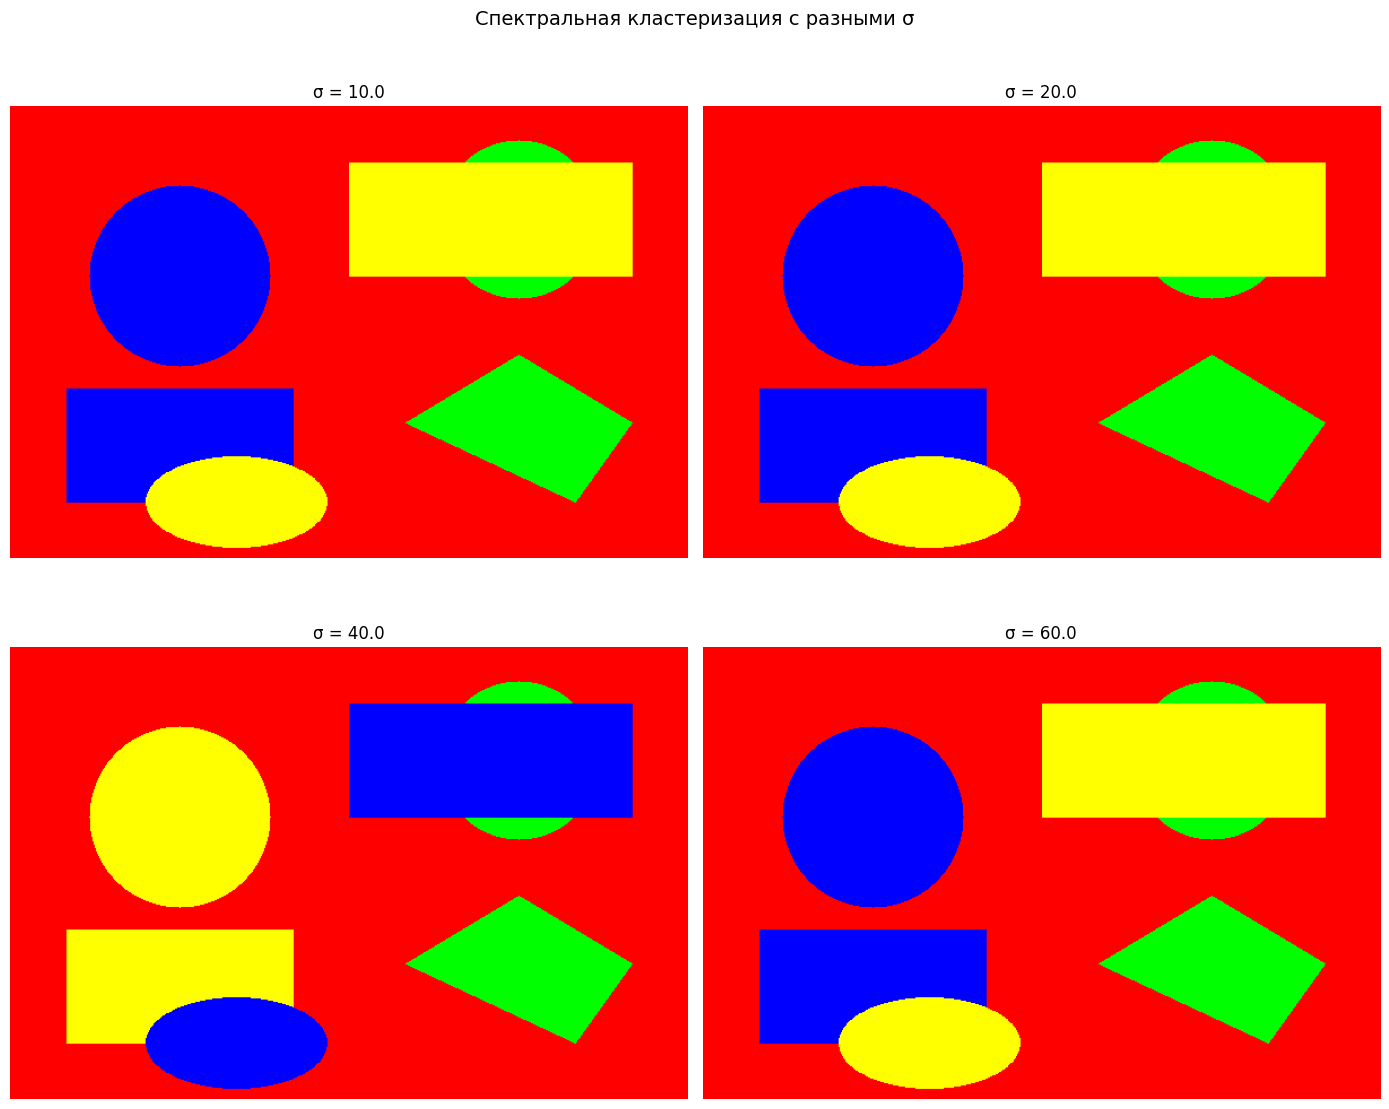

СРАВНЕНИЕ ТРЁХ МЕТОДОВ:
1.K-Means:
Время выполнения K-Means: 0.4627 секунд
2.Иерархическая:
Время выполнения Иерархической: 0.5753 секунд
3.Спектральная:
Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
Используем 5000 пикселей
Время выполнения Спектральной: 7.6253 секунд


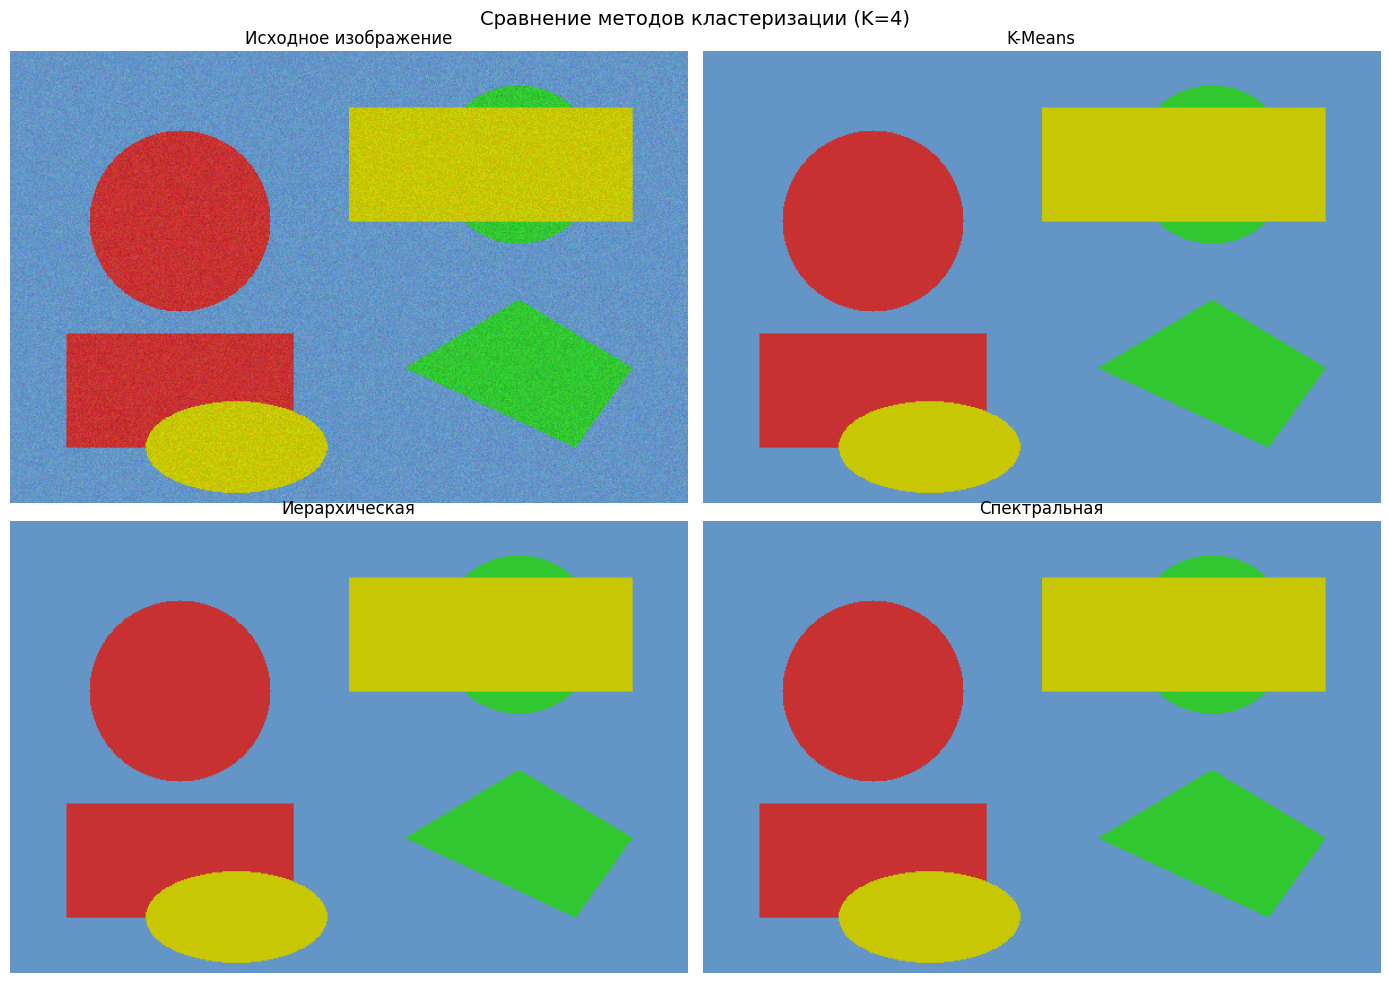

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import SpectralClustering
import time
import os
from sklearn.neighbors import NearestNeighbors

def spectral_clustering_image(pixels, K, sigma=1.0):

    print(f"Выполняем спектральную кластеризацию (K={K}, sigma={sigma})...")

    n_samples = min(len(pixels), 5000)
    sample_idx = np.random.choice(len(pixels), n_samples, replace=False)
    pixels_sample = pixels[sample_idx]

    print(f"Используем {n_samples} пикселей")

    spectral = SpectralClustering(n_clusters=K, affinity='rbf', gamma=1/(2*sigma**2),
                                 random_state=42, n_init=10)
    labels_sample = spectral.fit_predict(pixels_sample)

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(pixels_sample)

    distances, indices = nn.kneighbors(pixels)
    labels = labels_sample[indices.flatten()]

    return labels, labels_sample, pixels_sample

sigmas = [10.0, 20.0, 40.0, 60.0]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

K = 4

for i, sigma in enumerate(sigmas):
    labels, _, _ = spectral_clustering_image(pixels, K, sigma=sigma)

    colors_palette = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0],
                               [255, 0, 255], [0, 255, 255]])

    colored = colors_palette[labels % len(colors_palette)]
    spectral_img = colored.reshape(img.shape)

    axes[i].imshow(spectral_img)
    axes[i].set_title(f'σ = {sigma}')
    axes[i].axis('off')

plt.suptitle('Спектральная кластеризация с разными σ', fontsize=14)
plt.tight_layout()
plt.show()

print("СРАВНЕНИЕ ТРЁХ МЕТОДОВ:")

K = 4

print("1.K-Means:")
start_time_km = time.time()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
ret, labels_km, centers_km = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
centers_km = centers_km.astype(np.uint8)
segmented_km = centers_km[labels_km.flatten()].reshape(img.shape)
end_time_km = time.time()
elapsed_time_km = end_time_km - start_time_km
print(f"Время выполнения K-Means: {elapsed_time_km:.4f} секунд")

print("2.Иерархическая:")
start_time_hier = time.time()
sample_size_hier = 2000
sample_idx_hier = np.random.choice(len(pixels), sample_size_hier, replace=False)
pixels_hier_sample = pixels[sample_idx_hier]

Z = linkage(pixels_hier_sample, method='ward')
labels_hier_sample = fcluster(Z, K, criterion='maxclust') - 1
nn_hier = NearestNeighbors(n_neighbors=1)
nn_hier.fit(pixels_hier_sample)
distances_hier, indices_hier = nn_hier.kneighbors(pixels)
labels_hier_full = labels_hier_sample[indices_hier.flatten()]

centers_hier = np.array([np.mean(pixels[labels_hier_full == k], axis=0) for k in range(K)]).astype(np.uint8)
segmented_hier = centers_hier[labels_hier_full].reshape(img.shape)
end_time_hier = time.time()
elapsed_time_hier = end_time_hier - start_time_hier
print(f"Время выполнения Иерархической: {elapsed_time_hier:.4f} секунд")

print("3.Спектральная:")
start_time_spec = time.time()
labels_spec, _, _ = spectral_clustering_image(pixels, K, sigma=20.0)
centers_spec = np.array([np.mean(pixels[labels_spec == k], axis=0) for k in range(K)]).astype(np.uint8)
segmented_spec = centers_spec[labels_spec].reshape(img.shape)
end_time_spec = time.time()
elapsed_time_spec = end_time_spec - start_time_spec
print(f"Время выполнения Спектральной: {elapsed_time_spec:.4f} секунд")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Исходное изображение')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(segmented_km, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('K-Means')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(segmented_hier, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Иерархическая')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(segmented_spec, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Спектральная')
axes[1, 1].axis('off')

plt.suptitle('Сравнение методов кластеризации (K=4)', fontsize=14)
plt.tight_layout()
plt.show()

Выполняем спектральную кластеризацию (K=4, sigma=10.0)...
Используем 5000 пикселей
Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
Используем 5000 пикселей
Выполняем спектральную кластеризацию (K=4, sigma=40.0)...
Используем 5000 пикселей
Выполняем спектральную кластеризацию (K=4, sigma=60.0)...
Используем 5000 пикселей


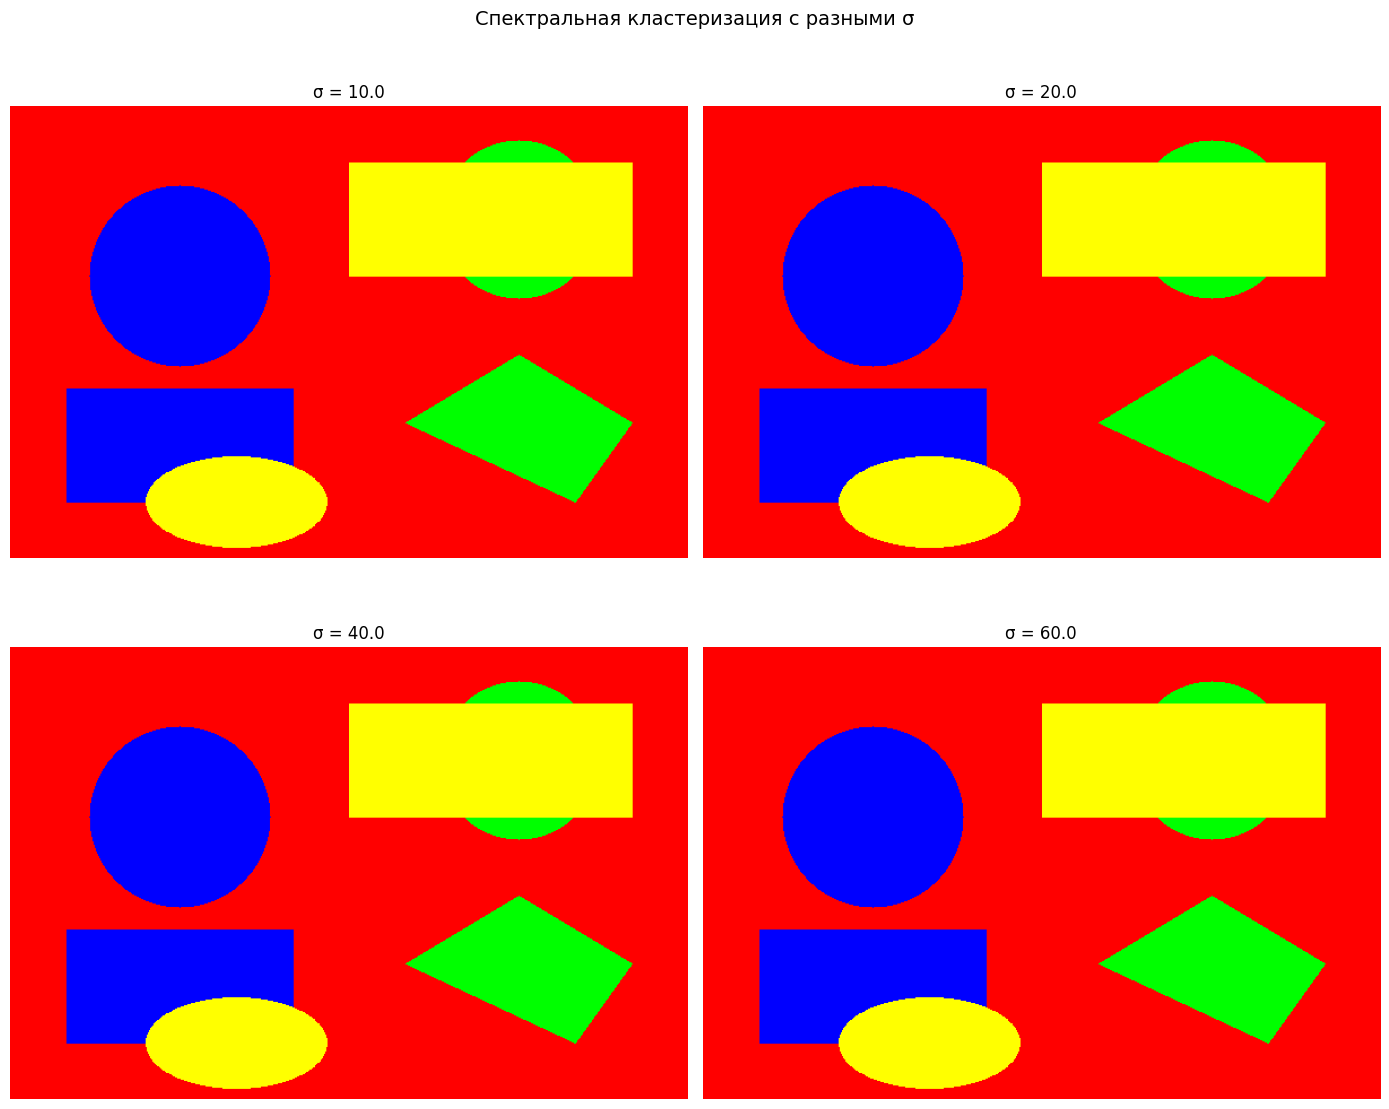

СРАВНЕНИЕ ТРЁХ МЕТОДОВ:
1.K-Means:
Время выполнения K-Means: 0.4777 секунд
Silhouette Score K-Means: 0.8404
2.Иерархическая:
Время выполнения Иерархической: 0.9944 секунд
Silhouette Score Иерархическая: 0.8404
3.Спектральная:
Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
Используем 5000 пикселей
Время выполнения Спектральной: 7.7784 секунд
Silhouette Score Спектральная: 0.8404


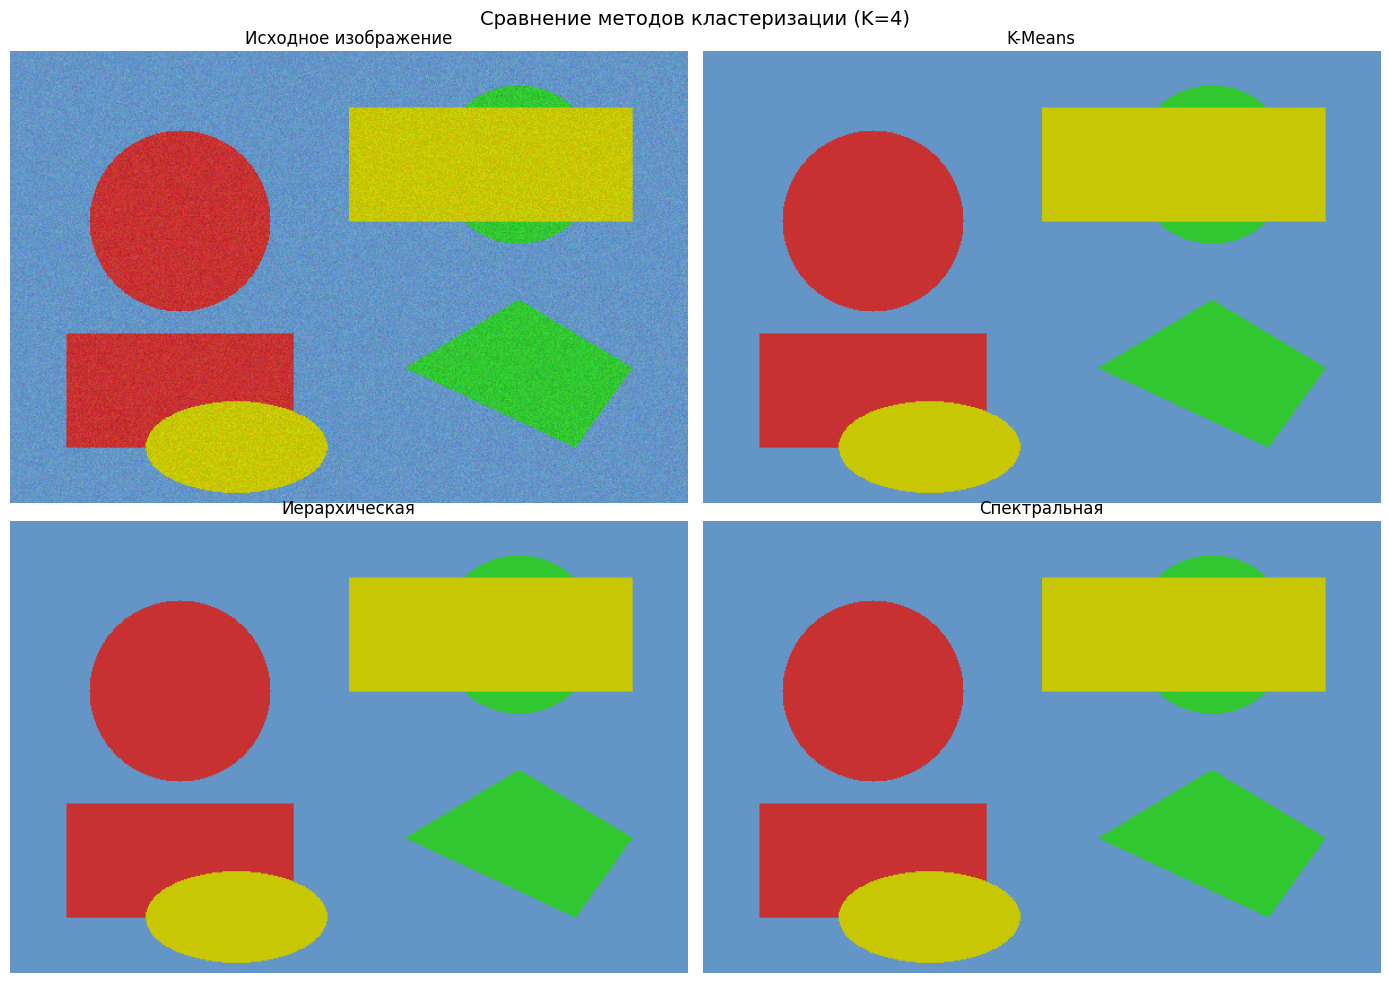

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import SpectralClustering
import time
import os
from sklearn.neighbors import NearestNeighbors

def spectral_clustering_image(pixels, K, sigma=1.0):

    print(f"Выполняем спектральную кластеризацию (K={K}, sigma={sigma})...")

    n_samples = min(len(pixels), 5000)
    sample_idx = np.random.choice(len(pixels), n_samples, replace=False)
    pixels_sample = pixels[sample_idx]

    print(f"Используем {n_samples} пикселей")

    spectral = SpectralClustering(n_clusters=K, affinity='rbf', gamma=1/(2*sigma**2),
                                 random_state=42, n_init=10)
    labels_sample = spectral.fit_predict(pixels_sample)

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(pixels_sample)

    distances, indices = nn.kneighbors(pixels)
    labels = labels_sample[indices.flatten()]

    return labels, labels_sample, pixels_sample

sigmas = [10.0, 20.0, 40.0, 60.0]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

K = 4

for i, sigma in enumerate(sigmas):
    labels, _, _ = spectral_clustering_image(pixels, K, sigma=sigma)

    colors_palette = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0],
                               [255, 0, 255], [0, 255, 255]])

    colored = colors_palette[labels % len(colors_palette)]
    spectral_img = colored.reshape(img.shape)

    axes[i].imshow(spectral_img)
    axes[i].set_title(f'σ = {sigma}')
    axes[i].axis('off')

plt.suptitle('Спектральная кластеризация с разными σ', fontsize=14)
plt.tight_layout()
plt.show()

print("СРАВНЕНИЕ ТРЁХ МЕТОДОВ:")

K = 4

print("1.K-Means:")
start_time_km = time.time()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
ret, labels_km, centers_km = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
centers_km = centers_km.astype(np.uint8)
segmented_km = centers_km[labels_km.flatten()].reshape(img.shape)
end_time_km = time.time()
elapsed_time_km = end_time_km - start_time_km
print(f"Время выполнения K-Means: {elapsed_time_km:.4f} секунд")
silhouette_km = silhouette_score(pixels, labels_km.flatten(), sample_size=2000, random_state=42)
print(f"Silhouette Score K-Means: {silhouette_km:.4f}")

print("2.Иерархическая:")
start_time_hier = time.time()
sample_size_hier = 2000
sample_idx_hier = np.random.choice(len(pixels), sample_size_hier, replace=False)
pixels_hier_sample = pixels[sample_idx_hier]

Z = linkage(pixels_hier_sample, method='ward')
labels_hier_sample = fcluster(Z, K, criterion='maxclust') - 1
nn_hier = NearestNeighbors(n_neighbors=1)
nn_hier.fit(pixels_hier_sample)
distances_hier, indices_hier = nn_hier.kneighbors(pixels)
labels_hier_full = labels_hier_sample[indices_hier.flatten()]

centers_hier = np.array([np.mean(pixels[labels_hier_full == k], axis=0) for k in range(K)]).astype(np.uint8)
segmented_hier = centers_hier[labels_hier_full].reshape(img.shape)
end_time_hier = time.time()
elapsed_time_hier = end_time_hier - start_time_hier
print(f"Время выполнения Иерархической: {elapsed_time_hier:.4f} секунд")
silhouette_hier = silhouette_score(pixels, labels_hier_full, sample_size=2000, random_state=42)
print(f"Silhouette Score Иерархическая: {silhouette_hier:.4f}")

print("3.Спектральная:")
start_time_spec = time.time()
labels_spec, _, _ = spectral_clustering_image(pixels, K, sigma=20.0)
centers_spec = np.array([np.mean(pixels[labels_spec == k], axis=0) for k in range(K)]).astype(np.uint8)
segmented_spec = centers_spec[labels_spec].reshape(img.shape)
end_time_spec = time.time()
elapsed_time_spec = end_time_spec - start_time_spec
print(f"Время выполнения Спектральной: {elapsed_time_spec:.4f} секунд")
silhouette_spec = silhouette_score(pixels, labels_spec, sample_size=2000, random_state=42)
print(f"Silhouette Score Спектральная: {silhouette_spec:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Исходное изображение')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(segmented_km, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('K-Means')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(segmented_hier, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Иерархическая')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(segmented_spec, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Спектральная')
axes[1, 1].axis('off')

plt.suptitle('Сравнение методов кластеризации (K=4)', fontsize=14)
plt.tight_layout()
plt.show()

Генерируем изображения для анализа масштабируемости:
  - small: 200x300 (число пикселей: 60000)
  - medium: 400x600 (число пикселей: 240000)
  - large: 480x720 (число пикселей: 345600)


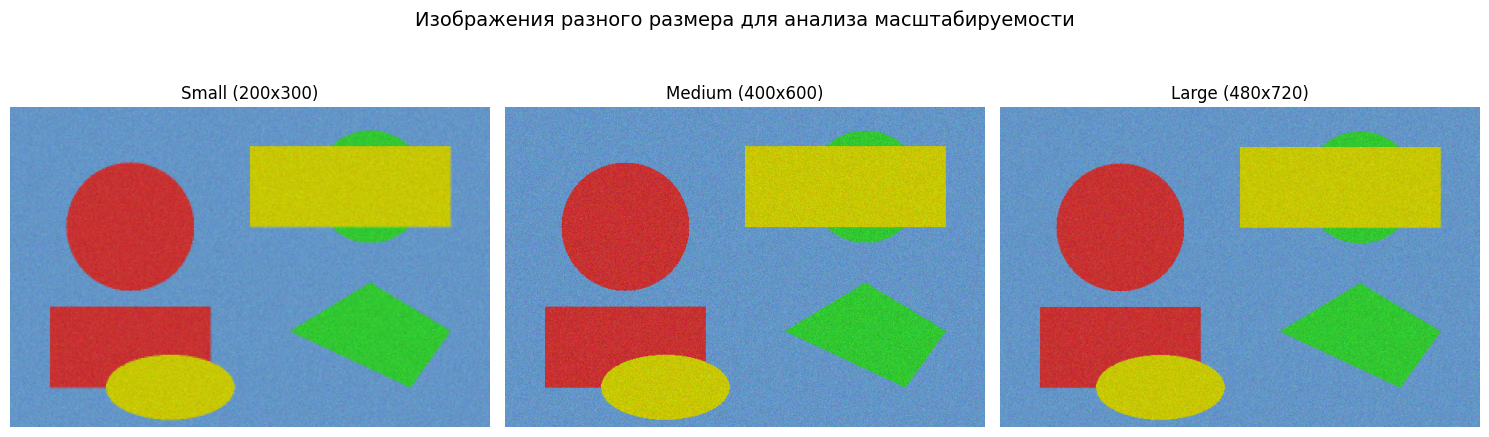

In [9]:
def create_resized_image(original_img, scale_factor):
    width = int(original_img.shape[1] * scale_factor)
    height = int(original_img.shape[0] * scale_factor)
    dim = (width, height)

    resized_img = cv2.resize(original_img, dim, interpolation=cv2.INTER_AREA)
    return resized_img

image_sizes = [(0.5, 'small'), (1.0, 'medium'), (1.2, 'large')]
scaled_images = {}

print("Генерируем изображения для анализа масштабируемости:")
for scale, name in image_sizes:
    scaled_images[name] = create_resized_image(img, scale)
    print(f"  - {name}: {scaled_images[name].shape[0]}x{scaled_images[name].shape[1]} (число пикселей: {scaled_images[name].shape[0] * scaled_images[name].shape[1]})")

fig, axes = plt.subplots(1, len(image_sizes), figsize=(15, 5))

for i, (scale, name) in enumerate(image_sizes):
    axes[i].imshow(cv2.cvtColor(scaled_images[name], cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'{name.capitalize()} ({scaled_images[name].shape[0]}x{scaled_images[name].shape[1]})')
    axes[i].axis('off')

plt.suptitle('Изображения разного размера для анализа масштабируемости', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
results = []

K = 4
sigma_spectral = 20.0

for name, current_img in scaled_images.items():
    print(f"Анализ для изображения: {name.capitalize()} ({current_img.shape[0]}x{current_img.shape[1]})")
    current_pixels = current_img.reshape(-1, 3).astype(np.float32)

    start_time = time.time()
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    ret, labels_km, centers_km = cv2.kmeans(current_pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    end_time = time.time()
    time_km = end_time - start_time
    score_km = silhouette_score(current_pixels, labels_km.flatten(), sample_size=min(len(current_pixels), 2000), random_state=42)
    print(f"K-Means: Время = {time_km:.4f} сек, Silhouette Score = {score_km:.4f}")
    results.append({
        'Image Size': name.capitalize(),
        'Pixels Count': current_pixels.shape[0],
        'Method': 'K-Means',
        'Time(s)': time_km,
        'Silhouette Score': score_km
    })

    start_time = time.time()
    sample_size_hier = min(len(current_pixels), 2000)
    sample_idx_hier = np.random.choice(len(current_pixels), sample_size_hier, replace=False)
    pixels_hier_sample = current_pixels[sample_idx_hier]
    Z = linkage(pixels_hier_sample, method='ward')
    labels_hier_sample = fcluster(Z, K, criterion='maxclust') - 1
    nn_hier = NearestNeighbors(n_neighbors=1)
    nn_hier.fit(pixels_hier_sample)
    distances_hier, indices_hier = nn_hier.kneighbors(current_pixels)
    labels_hier_full = labels_hier_sample[indices_hier.flatten()]
    end_time = time.time()
    time_hier = end_time - start_time
    score_hier = silhouette_score(current_pixels, labels_hier_full, sample_size=min(len(current_pixels), 2000), random_state=42)
    print(f"Иерархическая: Время = {time_hier:.4f} сек, Silhouette Score = {score_hier:.4f}")
    results.append({
        'Image Size': name.capitalize(),
        'Pixels Count': current_pixels.shape[0],
        'Method': 'Hierarchical',
        'Time(s)': time_hier,
        'Silhouette Score': score_hier
    })

    start_time = time.time()
    labels_spec, _, _ = spectral_clustering_image(current_pixels, K, sigma=sigma_spectral)
    end_time = time.time()
    time_spec = end_time - start_time
    score_spec = silhouette_score(current_pixels, labels_spec, sample_size=min(len(current_pixels), 2000), random_state=42)
    print(f"Спектральная: Время = {time_spec:.4f} сек, Silhouette Score = {score_spec:.4f}")
    results.append({
        'Image Size': name.capitalize(),
        'Pixels Count': current_pixels.shape[0],
        'Method': 'Spectral',
        'Time(s)': time_spec,
        'Silhouette Score': score_spec
    })

import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)


Анализ для изображения: Small (200x300)
K-Means: Время = 0.3173 сек, Silhouette Score = 0.9061
Иерархическая: Время = 0.2431 сек, Silhouette Score = 0.9053
Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
Используем 5000 пикселей
Спектральная: Время = 7.9582 сек, Silhouette Score = 0.9052
Анализ для изображения: Medium (400x600)
K-Means: Время = 0.4381 сек, Silhouette Score = 0.8404
Иерархическая: Время = 0.5536 сек, Silhouette Score = 0.8404
Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
Используем 5000 пикселей
Спектральная: Время = 8.9558 сек, Silhouette Score = 0.8404
Анализ для изображения: Large (480x720)
K-Means: Время = 0.6399 сек, Silhouette Score = 0.8793
Иерархическая: Время = 0.8123 сек, Silhouette Score = 0.8793
Выполняем спектральную кластеризацию (K=4, sigma=20.0)...
Используем 5000 пикселей
Спектральная: Время = 7.5462 сек, Silhouette Score = 0.8793


,Image Size,Pixels Count,Method,Time(s),Silhouette Score
0,Small,60000,K-Means,0.317305,0.906133
1,Small,60000,Hierarchical,0.243119,0.905269
2,Small,60000,Spectral,7.958208,0.905227
3,Medium,240000,K-Means,0.438053,0.840368
4,Medium,240000,Hierarchical,0.553552,0.840368
5,Medium,240000,Spectral,8.955848,0.840368
6,Large,345600,K-Means,0.639872,0.879318
7,Large,345600,Hierarchical,0.812308,0.879315
8,Large,345600,Spectral,7.546181,0.879308


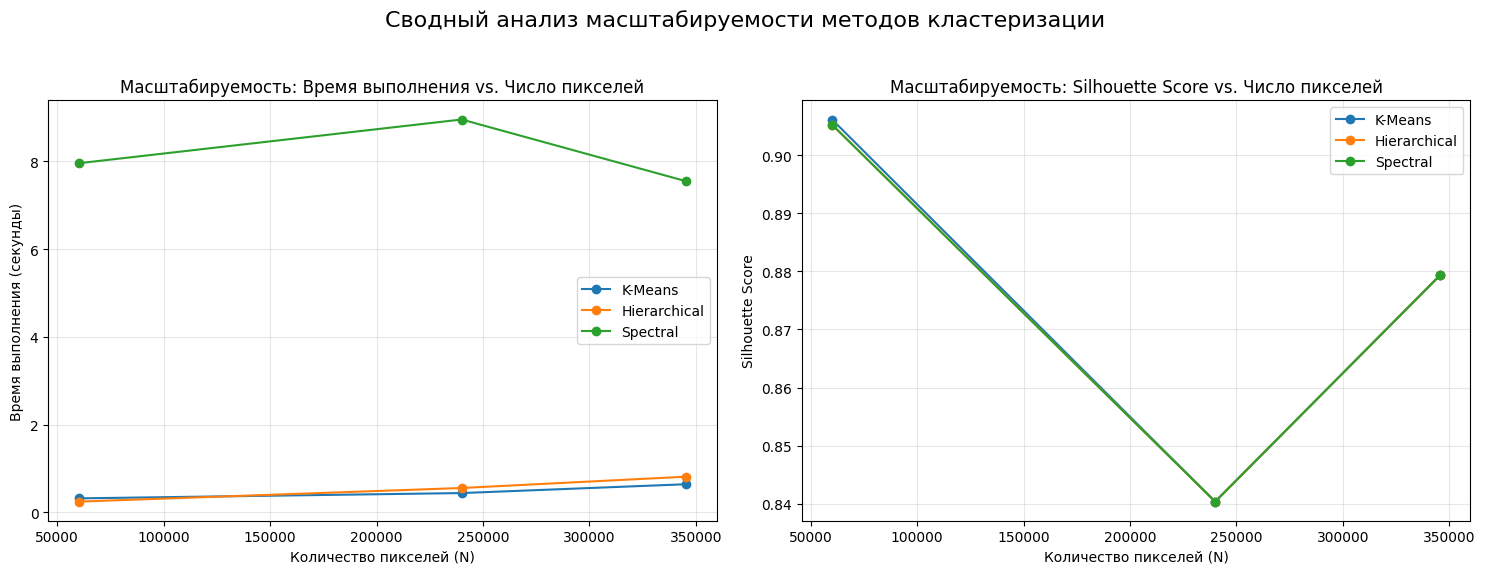

Таблица результатов:


,Image Size,Pixels Count,Method,Time(s),Silhouette Score
0,Small,60000,K-Means,0.317305,0.906133
1,Small,60000,Hierarchical,0.243119,0.905269
2,Small,60000,Spectral,7.958208,0.905227
3,Medium,240000,K-Means,0.438053,0.840368
4,Medium,240000,Hierarchical,0.553552,0.840368
5,Medium,240000,Spectral,8.955848,0.840368
6,Large,345600,K-Means,0.639872,0.879318
7,Large,345600,Hierarchical,0.812308,0.879315
8,Large,345600,Spectral,7.546181,0.879308


In [13]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for method in results_df['Method'].unique():
    method_data = results_df[results_df['Method'] == method]
    plt.plot(method_data['Pixels Count'], method_data['Time(s)'], marker='o', label=method)
plt.xlabel('Количество пикселей (N)')
plt.ylabel('Время выполнения (секунды)')
plt.title('Масштабируемость: Время выполнения vs. Число пикселей')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for method in results_df['Method'].unique():
    method_data = results_df[results_df['Method'] == method]
    plt.plot(method_data['Pixels Count'], method_data['Silhouette Score'], marker='o', label=method)
plt.xlabel('Количество пикселей (N)')
plt.ylabel('Silhouette Score')
plt.title('Масштабируемость: Silhouette Score vs. Число пикселей')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Сводный анализ масштабируемости методов кластеризации', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Таблица результатов:")
display(results_df)
